# 06_scarcity_forecasting_model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from load_data import load_model_data
from features import build_features
from models import prepare_forecast_data


df = load_model_data()
df = build_features(df)


df["scarcity_event"] = (df["pool_price"] > 300).astype(int)

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Scarcity rate: {df['scarcity_event'].mean():.4f}")


Shape: (48935, 125)
Date range: 2020-01-01 00:00:00 → 2025-07-31 23:00:00
Scarcity rate: 0.0705


/Users/brodiehasein/alberta-power-market/src/features.py:249: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df[feature].shift(lag)
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_22632/1230114104.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["scarcity_event"] = (df["pool_price"] > 300).astype(int)


In [2]:
HORIZONS = [0, 1, 3, 6, 12]

for h in HORIZONS:
    df[f"scarcity_t_plus_{h}"] = df["scarcity_event"].shift(-h)

/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_22632/4168703171.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"scarcity_t_plus_{h}"] = df["scarcity_event"].shift(-h)


In [3]:
base_features = [
    "net_load",
    "renewable_share",
    "gen_wind",
    "reserve_proxy_pct",
    "total_imports",
    "wind_instability_24h"
]

interaction_features = [
    "ramp_x_netload",
    "ramp_x_reserve"
]

features = base_features + interaction_features

In [ ]:
lagged_features = {
    h: [f'{f}_lag{h}' for f in features]
    for h in HORIZONS
}

#### Ranking Quality (AUC)

In [20]:
results = []

for h in HORIZONS:
    target = f"scarcity_t_plus_{h}"

    X_train, X_test, y_train, y_test, feature_names = prepare_forecast_data(
        df,
        lagged_features[h],
        target
    )

    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)

    results.append({"horizon": f"{h}h ahead", "auc": round(auc, 4)})

pd.DataFrame(results)

,horizon,auc
0,0h ahead,0.8599
1,1h ahead,0.8745
2,3h ahead,0.8186
3,6h ahead,0.6231
4,12h ahead,0.6796


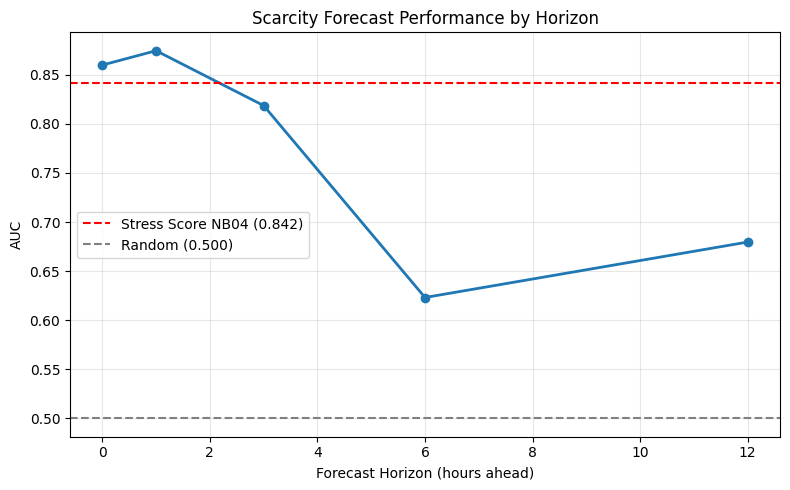

In [21]:
horizons = [0, 1, 3, 6, 12]
aucs = [0.8599, 0.8745, 0.8186, 0.6231, 0.6796]

plt.figure(figsize=(8, 5))
plt.plot(horizons, aucs, marker='o', linewidth=2)
plt.axhline(y=0.842, color='red', linestyle='--', label='Stress Score NB04 (0.842)')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Random (0.500)')
plt.xlabel("Forecast Horizon (hours ahead)")
plt.ylabel("AUC")
plt.title("Scarcity Forecast Performance by Horizon")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

alberta scarcity is not purely instantaneous chaos. it has short term persistence and structure. 
the system is picking up:
- ramping conditions
- wind decline pattersn
- reserve tightening
- load persistence

at hour 0 youre predicing current scarcity from current state, but price psikes are reactive and slightly delayed relative to system state signals. at 1h, were predicted lagged mianifestionation of system stress (i assume). because i wouldnt be able to explain that increase between 0 --> 1 otherwise. 

so we have strong ranking ability at 0-3 hours. but still pretty bad at actually classifying the events themselves. 

In [7]:
split_idx = int(len(df) * 0.8)
print(f"Training ends:  {df['timestamp'].iloc[split_idx]}")
print(f"Test set start: {df['timestamp'].iloc[split_idx + 1]}")
print(f"Test set end:   {df['timestamp'].iloc[-1]}")

Training ends:  2024-06-19 05:00:00
Test set start: 2024-06-19 06:00:00
Test set end:   2025-07-31 23:00:00


In [8]:
from sklearn.preprocessing import StandardScaler

test_years = [2022, 2023, 2024]
results = []

for test_year in test_years:
    train = df[df['timestamp'].dt.year < test_year]
    test  = df[df['timestamp'].dt.year == test_year]

    for h in HORIZONS:
        target = f"scarcity_t_plus_{h}"
        feature_set = lagged_features[h]

        train_clean = pd.concat([train[feature_set], train[target]], axis=1).dropna()
        test_clean  = pd.concat([test[feature_set],  test[target]],  axis=1).dropna()

        X_train = train_clean[feature_set]
        y_train = train_clean[target]
        X_test  = test_clean[feature_set]
        y_test  = test_clean[target]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        model = LogisticRegression(max_iter=1000, class_weight='balanced')
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probs)

        results.append({
            "test_year": test_year,
            "horizon": f"{h}h ahead",
            "auc": round(auc, 4)
        })

results_df = pd.DataFrame(results).pivot(
    index='horizon', 
    columns='test_year', 
    values='auc'
)
print(results_df)

test_year    2022    2023    2024
horizon                          
0h ahead   0.8279  0.8323  0.8863
12h ahead  0.7008  0.6128  0.7242
1h ahead   0.8226  0.8223  0.8732
3h ahead   0.7517  0.7901  0.8213
6h ahead   0.6609  0.6509  0.6865


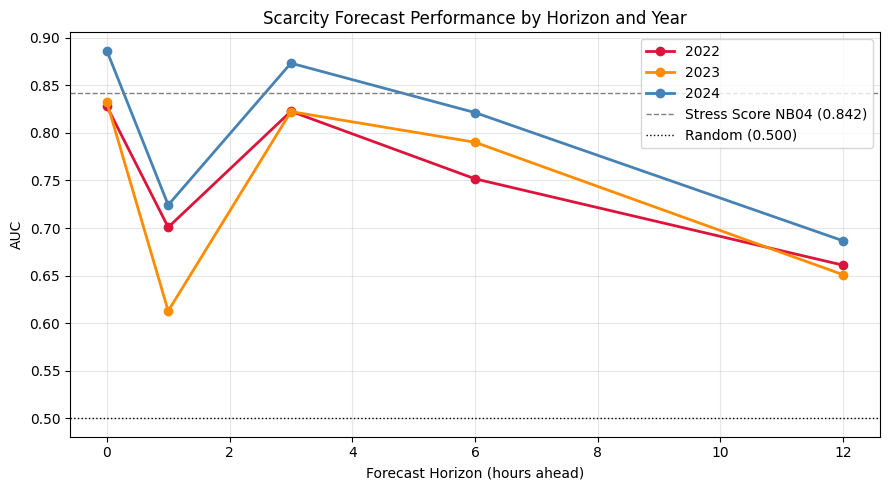

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

horizons = [0, 1, 3, 6, 12]
colors = {'2022': 'crimson', '2023': 'darkorange', '2024': 'steelblue'}

for year in [2022, 2023, 2024]:
    aucs = results_df[year].values
    ax.plot(horizons, aucs, marker='o', linewidth=2,
            label=str(year), color=colors[str(year)])

ax.axhline(y=0.842, color='gray', linestyle='--', linewidth=1,
           label='Stress Score NB04 (0.842)')
ax.axhline(y=0.5, color='black', linestyle=':', linewidth=1,
           label='Random (0.500)')

ax.set_xlabel("Forecast Horizon (hours ahead)")
ax.set_ylabel("AUC")
ax.set_title("Scarcity Forecast Performance by Horizon and Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2024 best overall --> maybe better quality data/ more extreme regimes
2023 dipped at a longer horizon --> regime shift year maybe (fuel mix/wind/gas/imports changed behaviour)

#### Calibration (reliability curve, calibration plot)

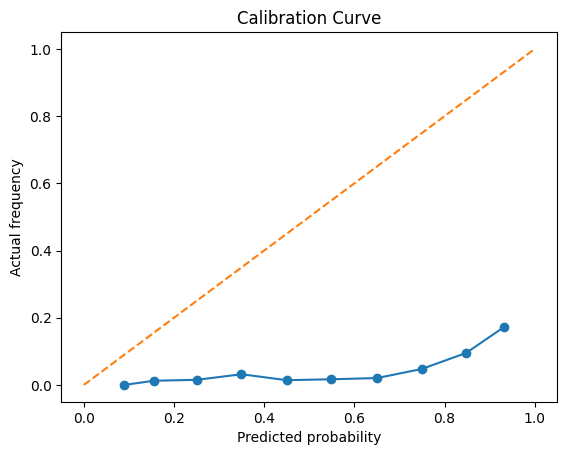

In [10]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    test[target],
    probs,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve")
plt.xlabel("Predicted probability")
plt.ylabel("Actual frequency")
plt.show()

curve below signal. probabilities are too confident, not well calibrated. but maybe common in logistic regression tests with: 
- imbalances
- interaction-heavy features
- correlated predictors

#### Theshold optimization (maxmize profit, maximize recall under precision constraint, minimize expected cost)

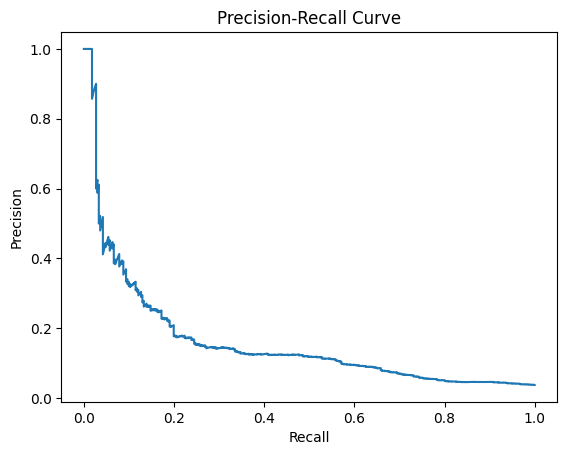

In [11]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(test[target], probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

scarcity prediction is a rare-event detection problem, not a balanced classifier problem. high sensitivity region --> noisy, high precisiion region --> very selective

In [ ]:

f1_scores = 2 * (precision * recall) / (precision + recall)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.918995384236973
Best F1: 0.2048780487804878


model is only acting when the system is very stressed. consistent with high precision region, energy risk aversion

Your optimal threshold of 0.92 from F1 maximization means: flag an hour as scarcity only when the model's risk score exceeds 0.92. At that point you get the best balance of precision and recall under equal weighting.

The F1 of 0.20 looks bad but reflects the class imbalance. With 7% scarcity rate, a perfect model would still have modest F1 without massive recall. It's not the right metric to optimize for this problem — AUC is more informative.

#### Economics Framing

In [13]:
cost_fp = 1
cost_fn = 10

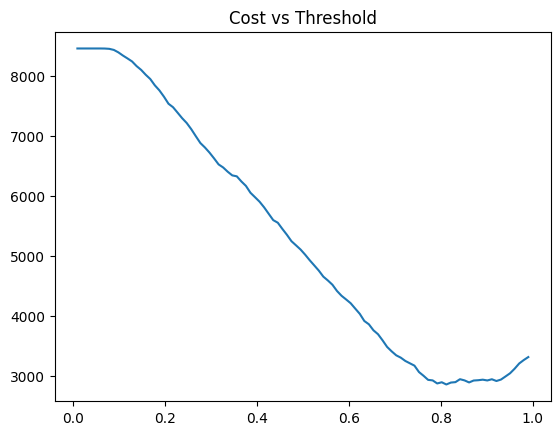

Optimal threshold: 0.8118181818181818


In [16]:
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01, 0.99, 100)

costs = []

for t in thresholds:
    preds = (probs > t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(test[target], preds).ravel()
    
    cost = fp * cost_fp + fn * cost_fn
    
    costs.append(cost)

best_t = thresholds[np.argmin(costs)]

plt.plot(thresholds, costs)
plt.title("Cost vs Threshold")
plt.show()

print("Optimal threshold:", best_t)

Your cost-optimized threshold of 0.81 means: when you weight a missed scarcity event 10x more costly than a false alarm, flag at 0.81.

#### regime transition analysis

In [17]:
df["entering_scarcity"] = (
    (df["scarcity_event"] == 1) &
    (df["scarcity_event"].shift(1) == 0)
)

/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_22632/1321612916.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["entering_scarcity"] = (


In [18]:
pre = df[df["entering_scarcity"].shift(-1) == True]

print(pre[features].mean())

net_load                9.501603e+03
renewable_share         9.241823e-02
gen_wind                4.467816e+02
reserve_proxy_pct       3.478247e-03
total_imports           4.398976e+02
wind_instability_24h    1.057933e+02
ramp_x_netload          1.771369e+06
ramp_x_reserve         -3.237851e-01
dtype: float64


In [19]:
normal = df[df["scarcity_event"] == 0]

comparison = pd.DataFrame({
    "pre_scarcity": pre[features].mean(),
    "normal": normal[features].mean()
})

comparison["diff"] = comparison["pre_scarcity"] - comparison["normal"]
print(comparison.sort_values("diff", ascending=False))

                      pre_scarcity        normal           diff
ramp_x_netload        1.771369e+06  1.389449e+06  381919.957507
net_load              9.501603e+03  8.529611e+03     971.991264
total_imports         4.398976e+02  3.166860e+02     123.211546
ramp_x_reserve       -3.237851e-01 -3.145567e+00       2.821782
reserve_proxy_pct     3.478247e-03  1.870065e-02      -0.015222
renewable_share       9.241823e-02  1.746391e-01      -0.082221
wind_instability_24h  1.057933e+02  1.265813e+02     -20.788060
gen_wind              4.467816e+02  1.089161e+03    -642.379214


before scarcity:
- net load goes up
- imports go up
- wind goes down
- renewable share does down
- reserve proxy slightly up (weird but noise/lag)

base variables already encode most of the signal, interaction features dont add a whole lot. interactions are redundant transformations. non-lienar re-expressions of existing signal. logistic regression distributes weight across correlated forms. 

would interaction features become more important in more "advanced", "regime-defined", or more accuracy-inclined models?

#### Missing variables

a. operational constraint variables
b. bid stack/ market design variables
c. fuel + thermal constraints
d. weather spatial structure
e. true system state
